# VALIDACIÓN CRUZADA (CROSS-VALIDATION)

## ¿Qué tan confiable es nuestro modelo Naive Bayes de prioridad de llamadas al 911?

¿El accuracy que vimos (0.89) fue buena suerte con **ESE** split en particular, o es un número confiable?

**CONTEXTO:** hasta ahora, cada vez que evaluamos un modelo (árbol, Random Forest, Naive Bayes) lo hicimos con UN SOLO split de 80%/20% train/test. Pero ese split se hizo con una semilla (`random_state`) específica. Si hubiéramos usado otra semilla, ¿el accuracy habría sido muy distinto?

La validación cruzada responde justamente esa pregunta: evalúa el modelo varias veces, con varias particiones distintas de los datos, para saber si el desempeño es **ESTABLE** o si depende mucho de qué datos cayeron en cada lado del split.

**Vamos a ver 4 variantes**, en orden de "menos repeticiones" a "más repeticiones" (y por lo tanto, de menos a más costoso computacionalmente):

1. **Hold-out simple** → 1 sola partición train/test (lo que ya conocemos)
2. **LOOCV** → cada registro, uno por uno, es el "conjunto de prueba"; se repite tantas veces como registros haya en la base (en nuestro caso, 1000 veces)
3. **K-Fold (k=5)** → se divide la base en 5 partes; cada parte sirve una vez como prueba, mientras las otras 4 son entrenamiento (5 repeticiones en total)
4. **Repeated K-Fold (10x3)** → se repite el proceso de K-Fold varias veces completas, cada vez con una división distinta, para promediar sobre más particiones aún


## PASO 0. Importar las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, LeaveOneOut,
                                       KFold, RepeatedKFold, cross_val_score)
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score

%matplotlib inline

## PASO 1. Cargar y preparar la base (igual que en el ejercicio de Naive Bayes)

**Nota:** ajusta la ruta del archivo CSV a donde tengas guardada tu base de datos en tu computadora.

In [2]:
datos = pd.read_csv(r"datos\base_911_prioridad.csv")

le_objetivo = LabelEncoder()
y = le_objetivo.fit_transform(datos["prioridad"])

X_texto = datos.drop(columns=["prioridad"])
encoder_X = OrdinalEncoder()
X = encoder_X.fit_transform(X_texto)

print(f"Base cargada: {X.shape[0]} llamadas, {X.shape[1]} variables predictoras")
print(f"Categorías de prioridad: {dict(zip(le_objetivo.classes_, range(len(le_objetivo.classes_))))}")

Base cargada: 1000 llamadas, 6 variables predictoras
Categorías de prioridad: {'Alta': 0, 'Baja': 1, 'Media': 2}


## PASO 2. Modelo 1 — Hold-out simple (referencia: lo que ya conocíamos)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12, stratify=y
)
modelo_holdout = CategoricalNB()
modelo_holdout.fit(X_train, y_train)
pred_holdout = modelo_holdout.predict(X_test)
accuracy_holdout = accuracy_score(y_test, pred_holdout)

print("\n" + "="*65)
print("MODELO 1 — HOLD-OUT SIMPLE (1 sola partición train/test)")
print("="*65)
print(f"Accuracy: {accuracy_holdout:.3f}")
print("""
LIMITACIÓN: este número depende de qué llamadas cayeron, por azar, en
el 20% de prueba. Si cambiáramos random_state, el accuracy podría subir
o bajar un poco — y no sabemos, con un solo número, qué tan grande es
esa variación. Para eso sirven las siguientes técnicas.
""")


MODELO 1 — HOLD-OUT SIMPLE (1 sola partición train/test)
Accuracy: 0.890

LIMITACIÓN: este número depende de qué llamadas cayeron, por azar, en
el 20% de prueba. Si cambiáramos random_state, el accuracy podría subir
o bajar un poco — y no sabemos, con un solo número, qué tan grande es
esa variación. Para eso sirven las siguientes técnicas.



## PASO 3. Modelo 2 — LOOCV (Leave-One-Out Cross-Validation)

**LA IDEA:** en lugar de un solo split 80/20, LOOCV entrena el modelo **TANTAS VECES** como registros tenga la base. En cada repetición, UN SOLO registro se aparta como "prueba" y los demás (999 en nuestro caso) se usan para entrenar. Al final, promediamos los 1000 resultados.

**VENTAJA:** usa casi toda la información disponible para entrenar en cada repetición — da una estimación con muy poco "desperdicio" de datos.

**DESVENTAJA:** es computacionalmente costoso, porque hay que entrenar el modelo una vez POR CADA registro de la base. Con modelos pesados (como una red neuronal) esto sería muy lento; pero Naive Bayes es muy rápido de entrenar, así que aquí SÍ es viable correr las 1000 iteraciones completas en pocos segundos.

In [4]:
modelo_loocv = CategoricalNB()
loocv = LeaveOneOut()

print("Corriendo LOOCV (1000 iteraciones)... esto toma unos segundos.")
scores_loocv = cross_val_score(modelo_loocv, X, y, cv=loocv)

print("\n" + "="*65)
print("MODELO 2 — LOOCV (1 registro a la vez, 1000 repeticiones)")
print("="*65)
print(f"Accuracy promedio: {scores_loocv.mean():.3f}")
print(f"(cada una de las 1000 repeticiones predice 1 sola llamada: acierto=1 o falla=0)")

print(f"""
COMPARACIÓN:
  Hold-out simple:  {accuracy_holdout:.3f}
  LOOCV:            {scores_loocv.mean():.3f}

Si ambos números son parecidos, es una buena señal: significa que el
accuracy de 0.89 que veníamos reportando NO fue un golpe de suerte del
split — el modelo es consistentemente bueno (o consistentemente malo)
sin importar qué datos exactos quedaron de un lado o del otro.
""")

Corriendo LOOCV (1000 iteraciones)... esto toma unos segundos.

MODELO 2 — LOOCV (1 registro a la vez, 1000 repeticiones)
Accuracy promedio: 0.892
(cada una de las 1000 repeticiones predice 1 sola llamada: acierto=1 o falla=0)

COMPARACIÓN:
  Hold-out simple:  0.890
  LOOCV:            0.892

Si ambos números son parecidos, es una buena señal: significa que el
accuracy de 0.89 que veníamos reportando NO fue un golpe de suerte del
split — el modelo es consistentemente bueno (o consistentemente malo)
sin importar qué datos exactos quedaron de un lado o del otro.



## PASO 4. Modelo 3 — K-Fold Cross-Validation (k=5)

**LA IDEA:** en vez de apartar un solo registro a la vez (como en LOOCV), dividimos la base en K partes ("folds") de tamaño parecido. En cada una de las K repeticiones, UNA parte sirve como prueba y las otras K-1 partes se usan para entrenar. Al final, promediamos las K evaluaciones.

Es un punto intermedio entre hold-out simple (1 repetición) y LOOCV (N repeticiones): con k=5, hacemos 5 repeticiones — mucho más barato que LOOCV, pero más confiable que un solo split.

In [5]:
kfold = KFold(n_splits=5, shuffle=True, random_state=12)
modelo_kfold = CategoricalNB()
scores_kfold = cross_val_score(modelo_kfold, X, y, cv=kfold)

print("\n" + "="*65)
print("MODELO 3 — K-FOLD (k=5, 5 repeticiones)")
print("="*65)
print("Accuracy en cada uno de los 5 folds:", scores_kfold.round(3))
print(f"Accuracy promedio: {scores_kfold.mean():.3f}")
print(f"Desviación estándar entre folds: {scores_kfold.std():.3f}")
print("""
La desviación estándar entre folds nos dice qué tan ESTABLE es el
modelo: si es pequeña, el accuracy no cambia mucho según qué datos
quedaron en cada partición; si es grande, el modelo es más sensible a
la composición exacta de los datos de entrenamiento.
""")


MODELO 3 — K-FOLD (k=5, 5 repeticiones)
Accuracy en cada uno de los 5 folds: [0.89  0.9   0.9   0.87  0.885]
Accuracy promedio: 0.889
Desviación estándar entre folds: 0.011

La desviación estándar entre folds nos dice qué tan ESTABLE es el
modelo: si es pequeña, el accuracy no cambia mucho según qué datos
quedaron en cada partición; si es grande, el modelo es más sensible a
la composición exacta de los datos de entrenamiento.



## PASO 5. Modelo 4 — Repeated K-Fold (10 folds x 3 repeticiones)

**LA IDEA:** hacemos K-Fold (esta vez con k=10) y repetimos TODO el proceso 3 veces completas, cada vez con una división distinta de los datos en folds. Esto da 10 x 3 = 30 evaluaciones en total, lo que produce una estimación todavía más estable que un solo K-Fold, porque promediamos sobre muchas más particiones posibles.

In [6]:
repeated_kfold = RepeatedKFold(n_splits=10, n_repeats=3, random_state=12)
modelo_repeated = CategoricalNB()
scores_repeated = cross_val_score(modelo_repeated, X, y, cv=repeated_kfold)

print("\n" + "="*65)
print("MODELO 4 — REPEATED K-FOLD (10 folds x 3 repeticiones = 30 evaluaciones)")
print("="*65)
print(f"Accuracy promedio: {scores_repeated.mean():.3f}")


MODELO 4 — REPEATED K-FOLD (10 folds x 3 repeticiones = 30 evaluaciones)
Accuracy promedio: 0.894


## PASO 6. Comparar los 4 métodos (tabla resumen + gráfico)

In [7]:
resumen = pd.DataFrame({
    "Método": ["Hold-out simple", "LOOCV", "K-Fold (k=5)", "Repeated K-Fold (10x3)"],
    "Repeticiones": [1, len(scores_loocv), len(scores_kfold), len(scores_repeated)],
    "Accuracy promedio": [accuracy_holdout, scores_loocv.mean(), scores_kfold.mean(), scores_repeated.mean()],
    # No incluimos desviación estándar para Hold-out (solo 1 repetición) ni
    # para LOOCV (cada repetición es 0/1, no es comparable con K-Fold — ver
    # nota técnica del Paso 3).
    "Desv. estándar": [np.nan, np.nan, scores_kfold.std(), scores_repeated.std()],
})
print("\n" + "="*65)
print("RESUMEN COMPARATIVO")
print("="*65)
print(resumen.round(3).to_string(index=False))


RESUMEN COMPARATIVO
                Método  Repeticiones  Accuracy promedio  Desv. estándar
       Hold-out simple             1              0.890             NaN
                 LOOCV          1000              0.892             NaN
          K-Fold (k=5)             5              0.889           0.011
Repeated K-Fold (10x3)            30              0.894           0.032


**LECTURA PARA ENTENDIMIENTO:**
- Entre más repeticiones, más confiable es la estimación del accuracy promedio — pero también más caro computacionalmente.
- Para un modelo tan rápido como Naive Bayes, LOOCV es perfectamente viable (corrió en segundos). Para modelos más pesados (como una red neuronal con miles de registros), LOOCV podría tardar horas, y ahí K-Fold es la alternativa práctica.
- Si los 4 métodos dan resultados parecidos, podemos confiar en que el accuracy ~0.89 de nuestro modelo es un número real y estable, no producto del azar de un solo split.

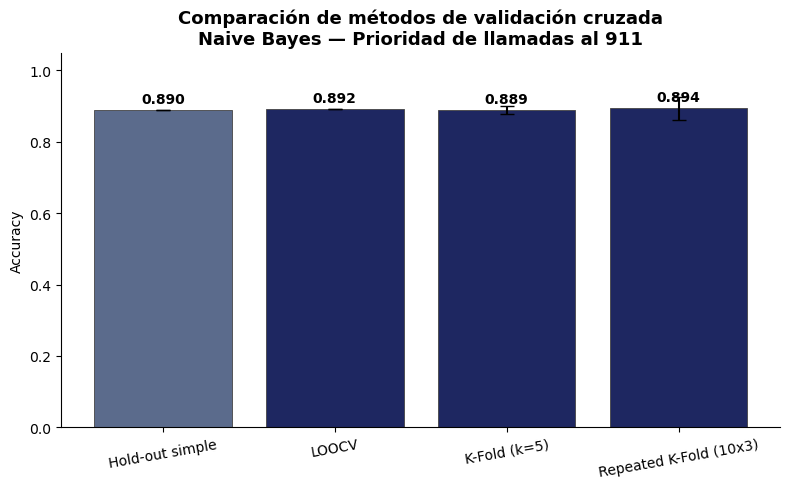

In [8]:
# --- Gráfico comparativo ---
fig, ax = plt.subplots(figsize=(8, 5))
metodos = resumen["Método"]
promedios = resumen["Accuracy promedio"]
errores = resumen["Desv. estándar"].fillna(0)

colores = ["#5B6B8C", "#1E2761", "#1E2761", "#1E2761"]
barras = ax.bar(metodos, promedios, color=colores, edgecolor="#444444", linewidth=0.6,
                  yerr=errores, capsize=5)
for barra, valor in zip(barras, promedios):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.02, f"{valor:.3f}",
            ha="center", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Comparación de métodos de validación cruzada\nNaive Bayes — Prioridad de llamadas al 911",
              fontsize=13, fontweight="bold")
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

---

# BOOTSTRAP

## ¿Qué tan precisa es nuestra estimación del accuracy del modelo Naive Bayes de prioridad de llamadas al 911?

**¿QUÉ ES BOOTSTRAP Y EN QUÉ SE PARECE/DIFERENCIA DE CROSS-VALIDATION?**

Ambas técnicas remuestrean los datos para entender qué tan confiable es una estimación, pero lo hacen de forma distinta:

- **Cross-validation** (lo que vimos arriba): DIVIDE los datos en partes que NO se repiten dentro de cada repetición (cada registro aparece como "prueba" como máximo una vez por repetición).

- **Bootstrap:** en cada remuestreo, toma una muestra del MISMO TAMAÑO que la base original, pero **CON REEMPLAZO** — es decir, un mismo registro puede aparecer varias veces en la muestra de entrenamiento (e incluso, por azar, algunos registros pueden no aparecer ninguna vez). A esos registros que NO fueron elegidos en una remuestra se les llama "out-of-bag" (fuera de la bolsa), y son justo los que usamos para evaluar el modelo en esa ronda — nunca evaluamos con datos que el modelo ya vio en esa remuestra particular.


## PASO 0. Importar las librerías necesarias

In [9]:
from sklearn.utils import resample

## PASO 1. Cargar y preparar la base (igual que en los ejercicios anteriores)

Reutilizamos `X` y `y` que ya preparamos arriba.

In [10]:
n = len(y)
print(f"Base cargada: {n} llamadas, {X.shape[1]} variables predictoras")

Base cargada: 1000 llamadas, 6 variables predictoras


## PASO 2. Un solo remuestreo bootstrap (para entender la mecánica)

In [11]:
np.random.seed(12)

# resample(..., replace=True) elige n índices CON reemplazo: algunos
# registros originales pueden salir 2, 3 o más veces; otros, ninguna.
indices_remuestra = resample(np.arange(n), replace=True, n_samples=n, random_state=0)

# Los índices que NO aparecieron en la remuestra son nuestro "out-of-bag":
# datos frescos que el modelo no vio al entrenar con esta remuestra.
indices_oob = np.setdiff1d(np.arange(n), indices_remuestra)

print(f"\nEjemplo de UN remuestreo bootstrap:")
print(f"  Tamaño de la remuestra de entrenamiento: {len(indices_remuestra)} (igual que el original, {n})")
print(f"  Registros únicos que SÍ aparecieron: {len(np.unique(indices_remuestra))}")
print(f"  Registros que NO aparecieron (out-of-bag): {len(indices_oob)}")
print("""
Imagina que tienes tus 1,000 llamadas escritas en papelitos dentro de una bolsa. 
Para hacer una remuestra, saca un papelito, anota qué dice, y devuélvelo a la bolsa 
antes de sacar el siguiente. Repites esto 1,000 veces (el mismo tamaño que la base original). 
Como vas regresando cada papelito, es perfectamente posible sacar la misma llamada dos, 
tres o más veces — y por pura casualidad, algunas llamadas nunca saldrán elegidas en esas 
1,000 extracciones. Por eso, al final, tu "remuestra de entrenamiento" tiene 1,000 
registros en total, pero muchos son repetidos, así que en realidad solo cubre unos 
630-650 registros distintos del original.
Los que nunca salieron elegidos (los otros 350-370) son justo los que llamamos 
"out-of-bag" — literalmente, "fuera de la bolsa": el modelo nunca los vio durante 
el entrenamiento de esa remuestra en particular, así que son perfectos para usarlos 
como datos de prueba "limpios" sin tener que apartar un 20% por separado como 
hacíamos con train_test_split.
""")
print("""
Es normal que se repitan varios registros y que otros queden fuera: en
promedio, cada remuestreo bootstrap deja afuera (out-of-bag) alrededor
del 37% de los datos originales — es una propiedad matemática del
muestreo con reemplazo, no un error.
""")


Ejemplo de UN remuestreo bootstrap:
  Tamaño de la remuestra de entrenamiento: 1000 (igual que el original, 1000)
  Registros únicos que SÍ aparecieron: 650
  Registros que NO aparecieron (out-of-bag): 350

Imagina que tienes tus 1,000 llamadas escritas en papelitos dentro de una bolsa. 
Para hacer una remuestra, saca un papelito, anota qué dice, y devuélvelo a la bolsa 
antes de sacar el siguiente. Repites esto 1,000 veces (el mismo tamaño que la base original). 
Como vas regresando cada papelito, es perfectamente posible sacar la misma llamada dos, 
tres o más veces — y por pura casualidad, algunas llamadas nunca saldrán elegidas en esas 
1,000 extracciones. Por eso, al final, tu "remuestra de entrenamiento" tiene 1,000 
registros en total, pero muchos son repetidos, así que en realidad solo cubre unos 
630-650 registros distintos del original.
Los que nunca salieron elegidos (los otros 350-370) son justo los que llamamos 
"out-of-bag" — literalmente, "fuera de la bolsa": el modelo 

In [12]:
# Entrenamos con la remuestra y evaluamos con los datos out-of-bag
modelo_ejemplo = CategoricalNB()
modelo_ejemplo.fit(X[indices_remuestra], y[indices_remuestra])
pred_ejemplo = modelo_ejemplo.predict(X[indices_oob])
accuracy_ejemplo = accuracy_score(y[indices_oob], pred_ejemplo)
print(f"Accuracy de este único remuestreo (evaluado en los datos out-of-bag): {accuracy_ejemplo:.3f}")

Accuracy de este único remuestreo (evaluado en los datos out-of-bag): 0.909


## PASO 3. Repetir el bootstrap 100 veces

Repetimos el proceso del Paso 2 cien veces, cada vez con una remuestra distinta, y guardamos el accuracy de cada una.

In [13]:
n_bootstrap = 100
accuracies_bootstrap = []

for b in range(n_bootstrap):
    idx_train = resample(np.arange(n), replace=True, n_samples=n, random_state=b)
    idx_oob = np.setdiff1d(np.arange(n), idx_train)
    if len(idx_oob) == 0:
        continue  # caso extremadamente raro; lo saltamos por seguridad
    modelo_b = CategoricalNB()
    modelo_b.fit(X[idx_train], y[idx_train])
    pred_b = modelo_b.predict(X[idx_oob])
    accuracies_bootstrap.append(accuracy_score(y[idx_oob], pred_b))

accuracies_bootstrap = np.array(accuracies_bootstrap)

print("\n" + "="*65)
print(f"BOOTSTRAP — {len(accuracies_bootstrap)} remuestreos")
print("="*65)
print(f"Accuracy promedio: {accuracies_bootstrap.mean():.3f}")
print(f"Desviación estándar: {accuracies_bootstrap.std():.3f}")


BOOTSTRAP — 100 remuestreos
Accuracy promedio: 0.887
Desviación estándar: 0.017


## PASO 4. Cuantificar la incertidumbre: intervalo de confianza

In [14]:
promedio = accuracies_bootstrap.mean()
desv_std = accuracies_bootstrap.std()

limite_inferior = promedio - 2 * desv_std
limite_superior = promedio + 2 * desv_std

print(f"\nIntervalo de confianza aproximado al 95% para el accuracy:")
print(f"  Límite inferior = {promedio:.3f} - (2 × {desv_std:.3f}) = {limite_inferior:.3f}")
print(f"  Límite superior = {promedio:.3f} + (2 × {desv_std:.3f}) = {limite_superior:.3f}")
print(f"\n  Intervalo: [{limite_inferior:.3f} , {limite_superior:.3f}]")
print(f"""
LECTURA: hay aproximadamente un 95% de probabilidad de que el verdadero
accuracy "poblacional" del modelo (el que tendríamos si pudiéramos
evaluarlo con TODAS las llamadas posibles, no solo nuestra muestra de
{n}) se encuentre dentro de ese intervalo. Cuanto más angosto sea el
intervalo, más PRECISA es nuestra estimación del desempeño del modelo.
""")


Intervalo de confianza aproximado al 95% para el accuracy:
  Límite inferior = 0.887 - (2 × 0.017) = 0.853
  Límite superior = 0.887 + (2 × 0.017) = 0.921

  Intervalo: [0.853 , 0.921]

LECTURA: hay aproximadamente un 95% de probabilidad de que el verdadero
accuracy "poblacional" del modelo (el que tendríamos si pudiéramos
evaluarlo con TODAS las llamadas posibles, no solo nuestra muestra de
1000) se encuentre dentro de ese intervalo. Cuanto más angosto sea el
intervalo, más PRECISA es nuestra estimación del desempeño del modelo.



## PASO 5. Visualizar la distribución de los 100 accuracy

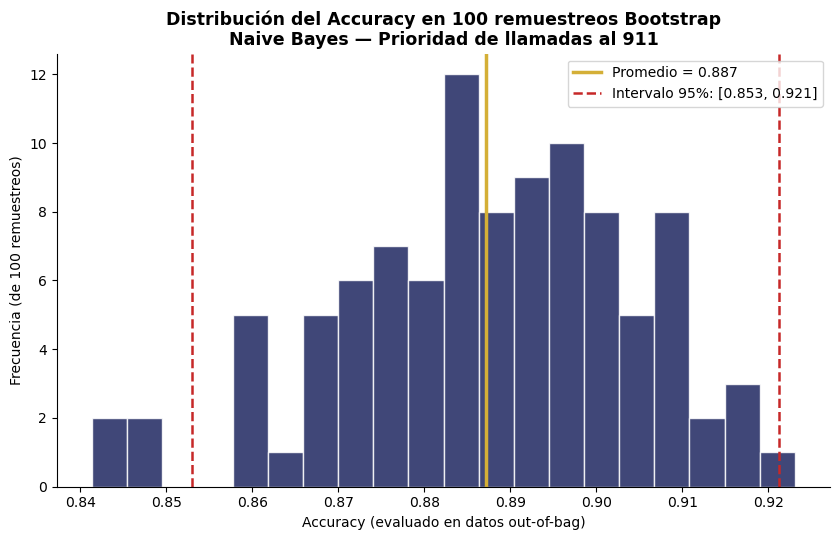


✅ Gráfico guardado como 'distribucion_bootstrap.png'


In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(accuracies_bootstrap, bins=20, color="#1E2761", edgecolor="white", alpha=0.85)
ax.axvline(promedio, color="#D4AF37", linewidth=2.5, label=f"Promedio = {promedio:.3f}")
ax.axvline(limite_inferior, color="#C62828", linewidth=1.8, linestyle="--",
           label=f"Intervalo 95%: [{limite_inferior:.3f}, {limite_superior:.3f}]")
ax.axvline(limite_superior, color="#C62828", linewidth=1.8, linestyle="--")

ax.set_xlabel("Accuracy (evaluado en datos out-of-bag)")
ax.set_ylabel("Frecuencia (de 100 remuestreos)")
ax.set_title("Distribución del Accuracy en 100 remuestreos Bootstrap\nNaive Bayes — Prioridad de llamadas al 911",
              fontsize=12.5, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("distribucion_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Gráfico guardado como 'distribucion_bootstrap.png'")

**CIERRE:**
- El histograma muestra que el accuracy NO es siempre exactamente 0.89: varía un poco de remuestreo a remuestreo, formando una distribución alrededor de un valor central.
- Esa variación es justamente lo que cuantifica el intervalo de confianza: nos dice qué tan seguros podemos estar del desempeño reportado, en lugar de quedarnos con un solo número "pelón" sin contexto de su variabilidad.
- Comparado con cross-validation (sección anterior), bootstrap tiende a dar una imagen más completa de la INCERTIDUMBRE del estimador, porque genera una distribución completa (100 valores) en lugar de solo un promedio y una desviación estándar de pocas repeticiones (como en K-Fold con apenas 5 o 10 valores).